# A3b — chaining the network along real particle paths

Loads only. The chains, the RK4 reference paths and the scores were written by
`build_chains.py` and `chain.py`; the figures by `plot_chains.py`.

| script | output |
|---|---|
| `build_chains.py` | `results/chains_{test,val}.npz`, `results/leg_d_test.npz`, `results/chains_meta.json` |
| `chain.py` | `results/chain_summary.csv`, `results/chains.csv`, `results/selection.csv`, `results/leg_d_reproduction.csv`, `results/example_paths.npz` |
| `plot_chains.py` | the three figures |


In [1]:
import json
import pandas as pd
from IPython.display import Image, display

meta = json.load(open("results/chains_meta.json"))
print(meta["rule"])
for s in ("test", "val"):
    print(s, meta[s]["particles_kept"], "particles,", meta[s]["legs_total"],
          "legs, lengths", meta[s]["n_legs_histogram"])
meta["leg_d_test"]

per particle: forward rows only; the planes they name, sorted and uniqued to 3 decimals, are the waypoints; consecutive waypoints are the legs; keep >= 4 legs
test 4563 particles, 23500 legs, lengths {'4': 1649, '5': 1433, '6': 628, '7': 853}
val 4551 particles, 23516 legs, lengths {'4': 1619, '5': 1408, '6': 668, '7': 856}


{'split': 'test',
 'particles_with_D_leg': 2726,
 'waypoint_from_own_B_leg': 1637,
 'waypoint_from_frozen_leg_z0': 1089,
 'dz_first_step_mm_median': -5178.247045898437,
 'dz_second_step_mm_median': -2651.4154677152633,
 'dz_whole_leg_mm_median': -7853.16176700592}

## How the error grows with the number of legs walked

In [2]:
cs = pd.read_csv("results/chain_summary.csv")
cs[(cs.split == "test") & cs.converged].pivot_table(
    index="step", columns=["width", "mode"], values="end_med_um",
    aggfunc="median")

width           50                         100                        200  \
mode           data       physics         data       physics         data   
step                                                                        
0        387.837388    440.312607   216.793457    246.257071   165.116726   
1       1275.180079   1422.921684   651.616873    783.237395   510.336886   
2       2225.477703   2562.360316  1051.090407   1443.327676   893.636621   
3       3634.496891   3919.235020  1483.790811   2292.650199  1489.661768   
4       6991.423832   8162.983499  2868.657354   4830.864957  2972.031253   
5      10086.651796  14479.118125  4819.579012   8904.428039  5695.225360   
6      10738.884793  15999.145719  5283.457377  10247.902518  6476.180725   

width                
mode        physics  
step                 
0        174.394389  
1        539.905673  
2       1029.368932  
3       1738.243282  
4       4132.968280  
5       8658.802263  
6      10450.492236

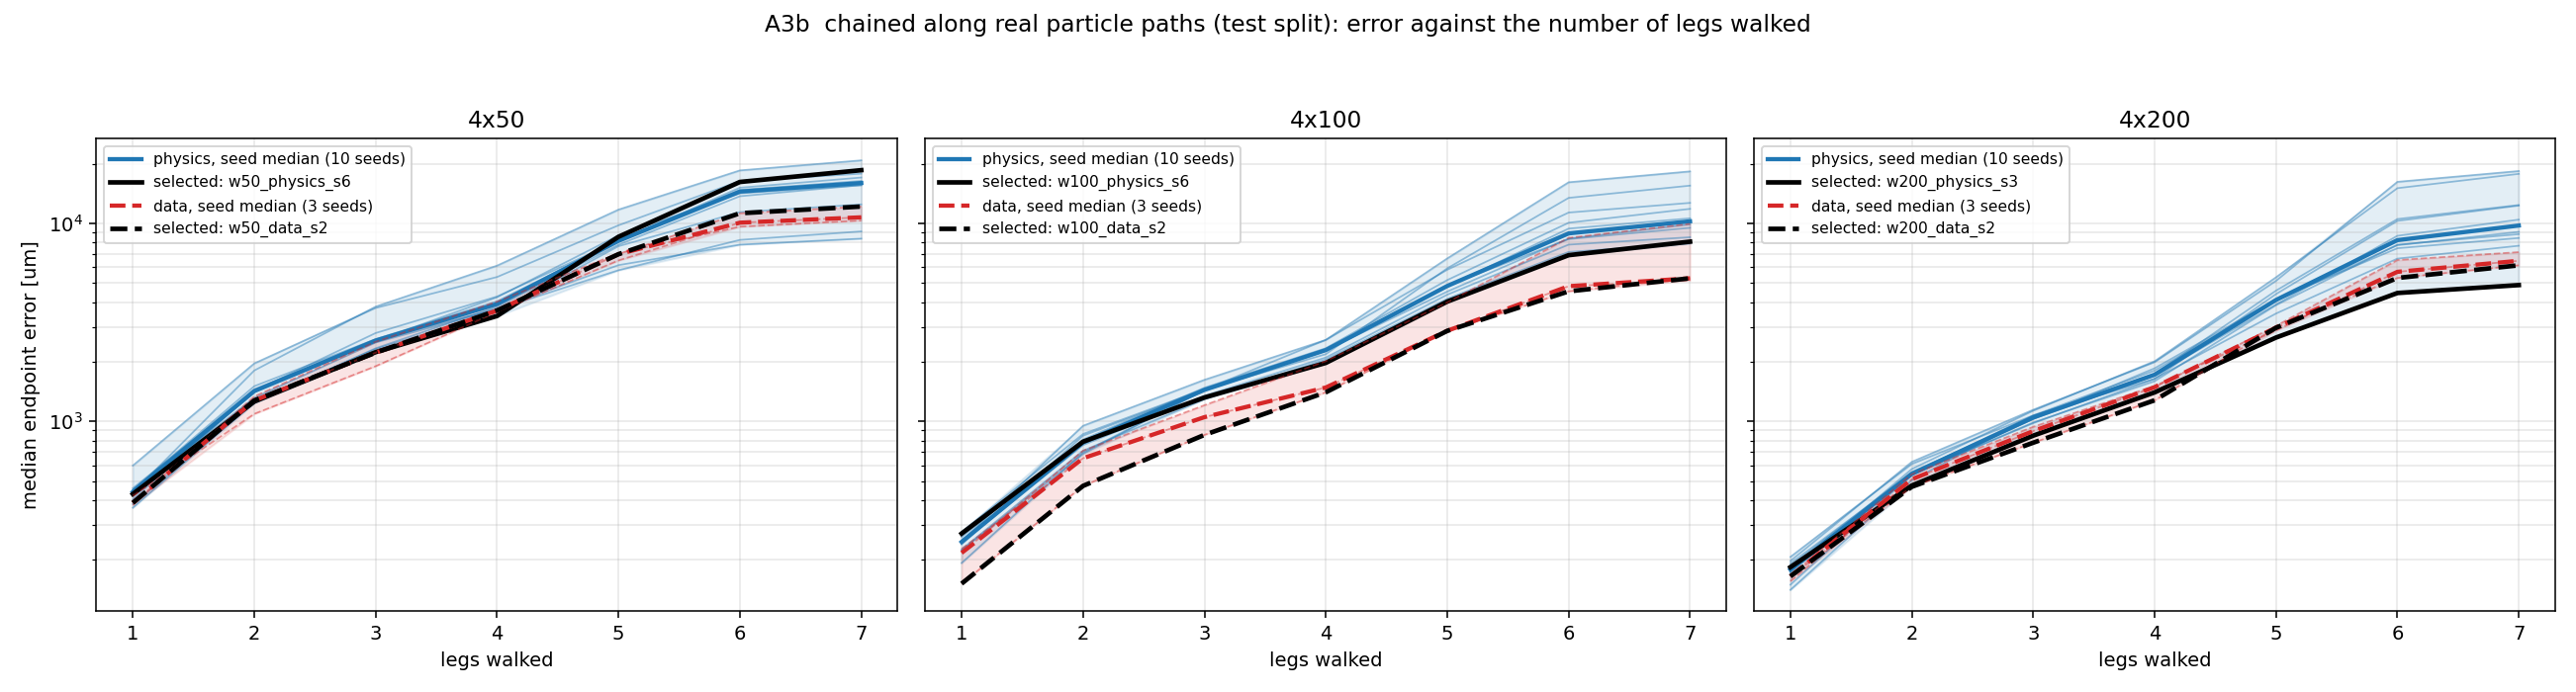

In [3]:
display(Image("figures/error_vs_chained_legs.png"))

## Which seed the val chains select, and whether the one-step error would have selected it

In [4]:
sel = pd.read_csv("results/selection.csv")
sel

,width,mode,network,rank_by_val_chain,chain_val_leg4_med_um,chain_test_leg4_med_um,one_step_val_med_um,selected
0,50,physics,w50_physics_s6,0.0,3715.149520,3408.662495,661.240617,True
1,50,physics,w50_physics_s1,1.0,3776.588421,3680.501583,724.725816,False
2,50,physics,w50_physics_s8,2.0,3997.255061,3704.957041,782.073766,False
3,50,physics,w50_physics_s4,3.0,4041.210460,3792.779359,650.297173,False
4,50,physics,w50_physics_s9,4.0,4109.867323,3570.681792,639.829759,False
5,50,physics,w50_physics_s0,5.0,4196.972117,4045.690681,854.349431,False
6,50,physics,w50_physics_s7,6.0,4543.111356,4274.647693,736.338829,False
7,50,physics,w50_physics_s5,7.0,4775.015314,4237.791245,737.375317,False
8,50,physics,w50_physics_s2,8.0,5610.923012,5363.211365,1246.374606,False
9,50,physics,w50_physics_s3,9.0,6564.542055,6122.072714,884.710497,False


## A few particles drawn out

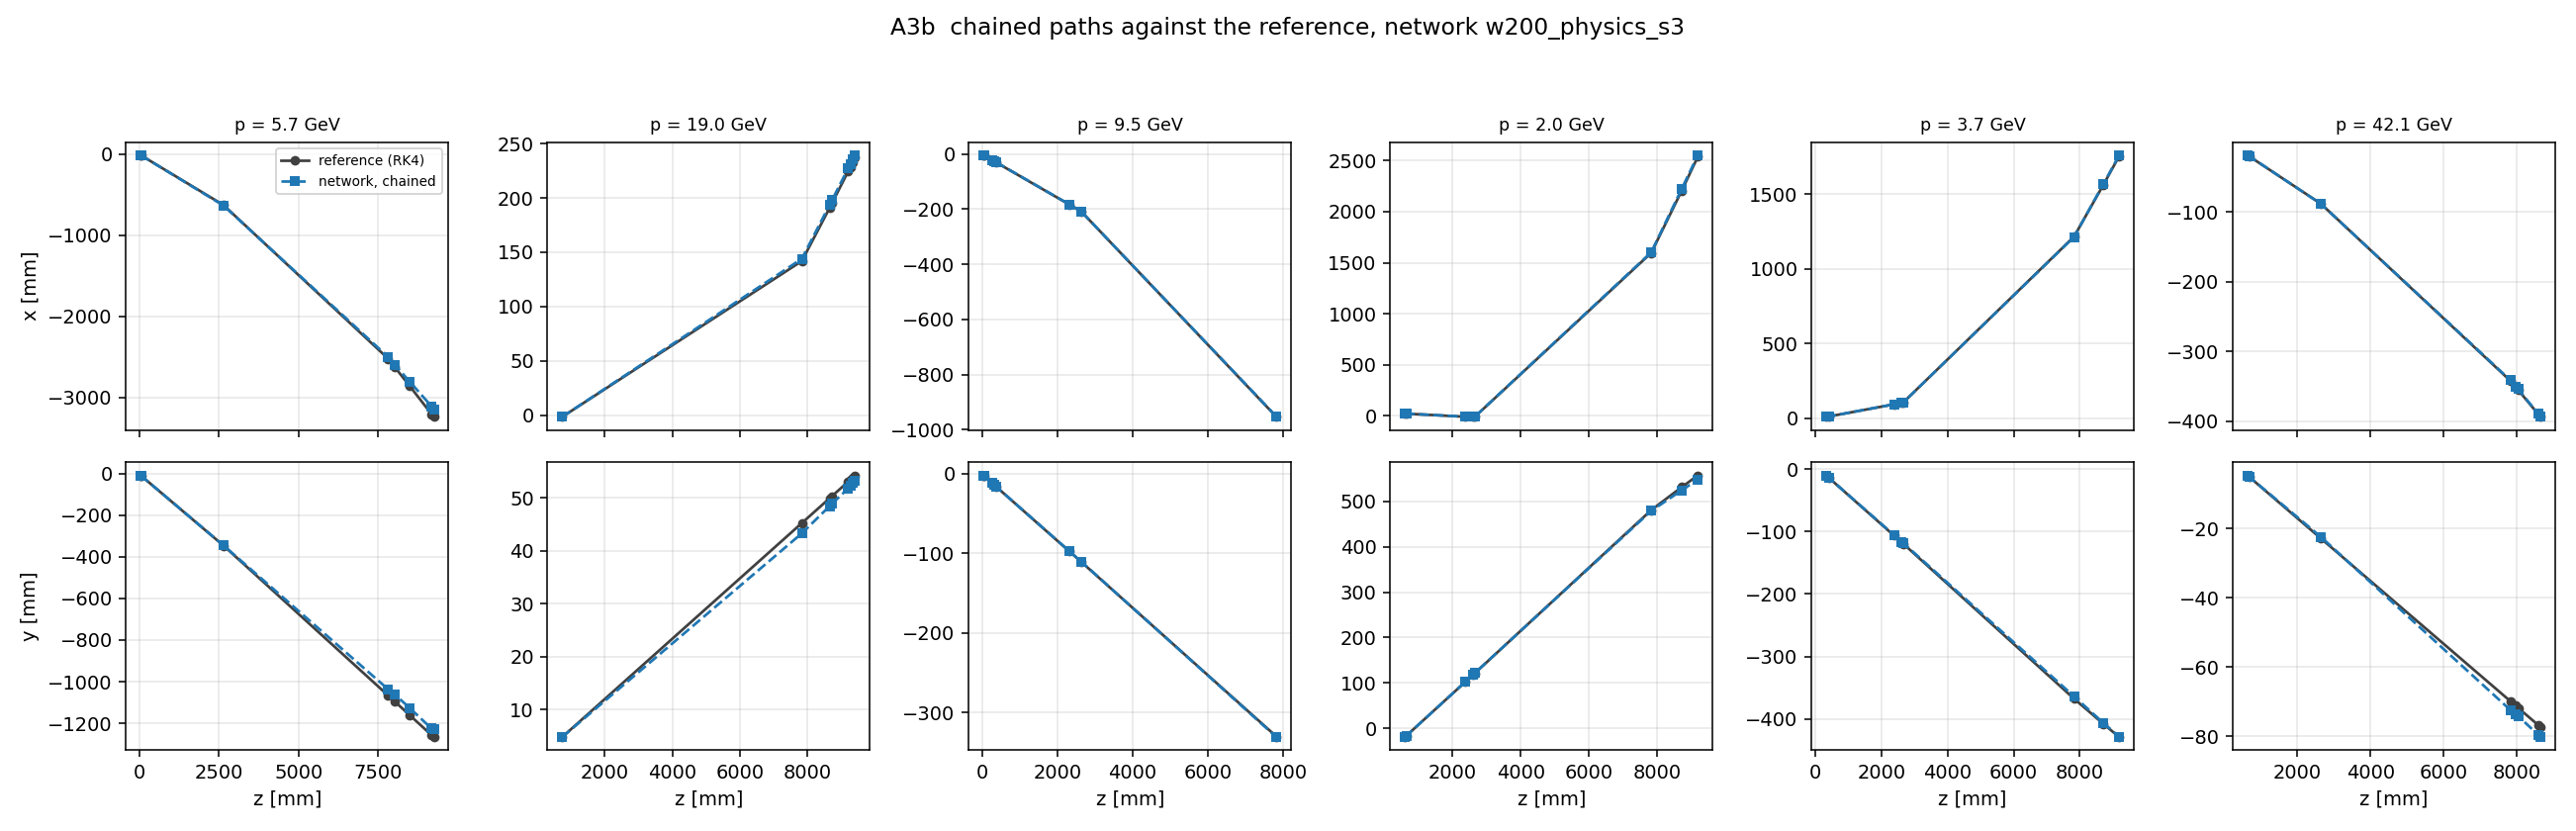

In [5]:
display(Image("figures/error_growth_examples.png"))

## Leg D: the same leg in two steps instead of one

In [6]:
d = pd.read_csv("results/leg_d_reproduction.csv")
d.pivot_table(index=["width", "mode"], columns="variant", values="med_um",
              aggfunc="median")

variant        composite_two_steps  single_giant_step
width mode                                           
50    data            34228.293813        6213.119116
      physics         47353.077903       17947.491518
100   data            33416.449508        3158.441764
      physics         59415.521643        8777.606848
200   data            30350.654344        2181.820273
      physics         36891.296476        4663.575389

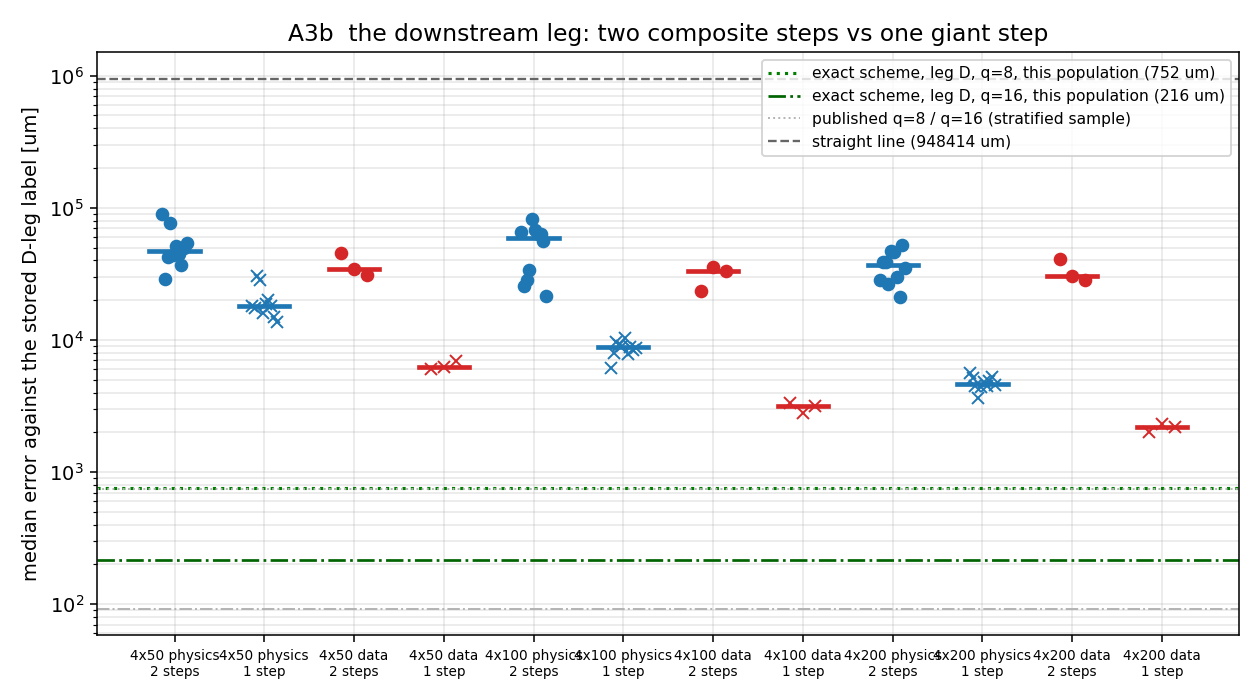

In [7]:
display(Image("figures/leg_d_reproduction.png"))